# Prediction of Bikecount

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor

import os
from dotenv import load_dotenv

plt.style.use("tableau-colorblind10")

RANDOM_STATE=42

/home/rene/dev/DSKI-KI-ML-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Daten laden

In [2]:
df=pd.read_csv(r"../data/hour.csv")

## Preprocessing- und Feature-Engineering

In [24]:
class DateEncoder(BaseEstimator, TransformerMixin):
    """Zyklisches Sin/Cos-Encoding von dteday für Jahres- und Monatssaisonalität
    sowie ein linearer Trend-Feature (Tage seit Datensatz-Start)."""

    def fit(self, X, y=None):
        if "dteday" in X.columns:
            self.start_date_ = pd.to_datetime(X["dteday"]).min()
        return self

    def transform(self, X):
        df = X.copy()
        if "dteday" not in df.columns:
            return df

        dates = pd.to_datetime(df["dteday"])
        day_of_year  = dates.dt.dayofyear   # 1–366
        day_of_month = dates.dt.day         # 1–31

        # Jährliche Saisonalität
        df["dteday_sin_year"] = np.sin(2 * np.pi * day_of_year  / 365.25)
        df["dteday_cos_year"] = np.cos(2 * np.pi * day_of_year  / 365.25)

        # Monatliche Saisonalität (feiner)
        df["dteday_sin_month"] = np.sin(2 * np.pi * day_of_month / 30.44)
        df["dteday_cos_month"] = np.cos(2 * np.pi * day_of_month / 30.44)

        # Linearer Trend
        df["days_since_start"] = (dates - self.start_date_).dt.days

        return df.drop(columns=["dteday"])


class BasicPreprocessor(BaseEstimator, TransformerMixin):
    """Drop irrelevanter Spalten (instant, casual, registered)."""
    DROP_COLS = ["instant", "casual", "registered"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        drop = [c for c in self.DROP_COLS if c in df.columns]
        print(drop)
        return df.drop(columns=drop)

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """OneHotEncoding für season, weathersit, mnth, hr, weekday."""
    CATEGORICAL_COLS = ["season", "weathersit", "mnth", "hr", "weekday"]

    def __init__(self):
        self.encoder_ = None
        self.cat_cols_present_ = None

    def fit(self, X, y=None):
        df = X.copy()
        self.cat_cols_present_ = [c for c in self.CATEGORICAL_COLS if c in df.columns]
        self.encoder_ = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.encoder_.fit(df[self.cat_cols_present_])
        return self

    def transform(self, X):
        df = X.copy()
        encoded = self.encoder_.transform(df[self.cat_cols_present_])
        encoded_df = pd.DataFrame(
            encoded,
            columns=self.encoder_.get_feature_names_out(self.cat_cols_present_),
            index=df.index,
        )
        return pd.concat([df.drop(columns=self.cat_cols_present_), encoded_df], axis=1)

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    """Lag-, Rolling- und Differenz-Features."""
    LAGS    = [1, 2, 3, 6, 12, 24, 48]
    WINDOWS = [3, 6, 12, 24]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        for lag in self.LAGS:
            df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)

        for window in self.WINDOWS:
            rolled = df["cnt"].shift(1).rolling(window)
            df[f"cnt_roll_mean_{window}"] = rolled.mean()
            df[f"cnt_roll_std_{window}"]  = rolled.std()
            df[f"cnt_roll_max_{window}"]  = rolled.max()

        df["cnt_diff_1"]  = df["cnt"].diff(1)
        df["cnt_diff_24"] = df["cnt"].diff(24)

        return df.dropna().reset_index(drop=True)

In [25]:
def build_pipeline() -> Pipeline:
    return Pipeline(steps=[
        ("date",       DateEncoder()),
        ("basic",      BasicPreprocessor()),
        ("timeseries", TimeSeriesFeatureEngineer()),
        ("ohe",        CategoricalEncoder()),
    ])

In [26]:
pipeline=build_pipeline()
df=pipeline.fit_transform(df)
X=df.drop(columns="cnt")
y=df["cnt"]
df.head()

['instant', 'casual', 'registered']


,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_1,season_2,...,cnt_roll_std_6,cnt_roll_max_6,cnt_roll_mean_12,cnt_roll_std_12,cnt_roll_max_12,cnt_roll_mean_24,cnt_roll_std_24,cnt_roll_max_24,cnt_diff_1,cnt_diff_24
0,0,0,1,0.20,0.1667,0.44,0.4179,2,1.0,0.0,...,11.640447,31.0,42.250000,27.775480,76.0,33.583333,29.759787,93.0,-3.0,-15.0
1,0,0,1,0.16,0.1364,0.47,0.3881,1,1.0,0.0,...,11.232394,31.0,36.166667,27.944208,76.0,32.958333,30.276234,93.0,-1.0,-16.0
2,0,0,1,0.16,0.1364,0.47,0.2836,3,1.0,0.0,...,11.075498,31.0,31.333333,28.643049,76.0,32.291667,30.814281,93.0,2.0,-6.0
3,0,0,1,0.14,0.1061,0.50,0.3881,30,1.0,0.0,...,3.265986,9.0,25.416667,26.262515,76.0,32.041667,31.035014,93.0,27.0,24.0
4,0,0,1,0.14,0.1364,0.50,0.1940,64,1.0,0.0,...,10.980285,30.0,21.583333,21.047385,65.0,33.041667,30.542172,93.0,34.0,61.0


## Train-Test-Split

In [6]:
ts_outer = TimeSeriesSplit(n_splits=2, test_size=3400)
outer_splits = list(ts_outer.split(X))
train_idx, test_idx = outer_splits[0]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

ts_cv = TimeSeriesSplit(n_splits=5, test_size=1500)


## Evaluierung

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
    }


def cross_validate_ts(model, X_tr, y_tr, cv):
    fold_maes = []
    for fold_train_idx, fold_val_idx in cv.split(X_tr):
        m = copy.deepcopy(model)
        m.fit(X_tr.iloc[fold_train_idx], y_tr.iloc[fold_train_idx])
        preds = m.predict(X_tr.iloc[fold_val_idx])
        fold_maes.append(mean_absolute_error(y_tr.iloc[fold_val_idx], preds))
    return np.mean(fold_maes), np.std(fold_maes)


def plot_predictions(r, y_test, n_plot=300):
    fig, ax = plt.subplots(figsize=(15, 3.5))
    y_true = y_test.values[:n_plot]
    n = min(n_plot, len(r['y_pred']))
    x_axis = range(n)
    ax.fill_between(x_axis, y_true[:n], alpha=0.15)
    ax.plot(x_axis, y_true[:n],      label='Wahrheit',   lw=1.2, alpha=0.8)
    ax.plot(x_axis, r['y_pred'][:n], label='Vorhersage', lw=1.0, alpha=0.9)
    ax.set_title(
        f"{r['name']}  |  MAE: {r['MAE']:.1f}  RMSE: {r['RMSE']:.1f}  R²: {r['R2']:.3f}",
        fontweight='bold', fontsize=11
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('cnt')
    ax.set_xlabel('Zeitschritt')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


all_results = []

## Modellierung
### Modellierung am Beispiel einer linearen Regression

### Modellierung am Beispiel eines HistGradientBoostingRegressor

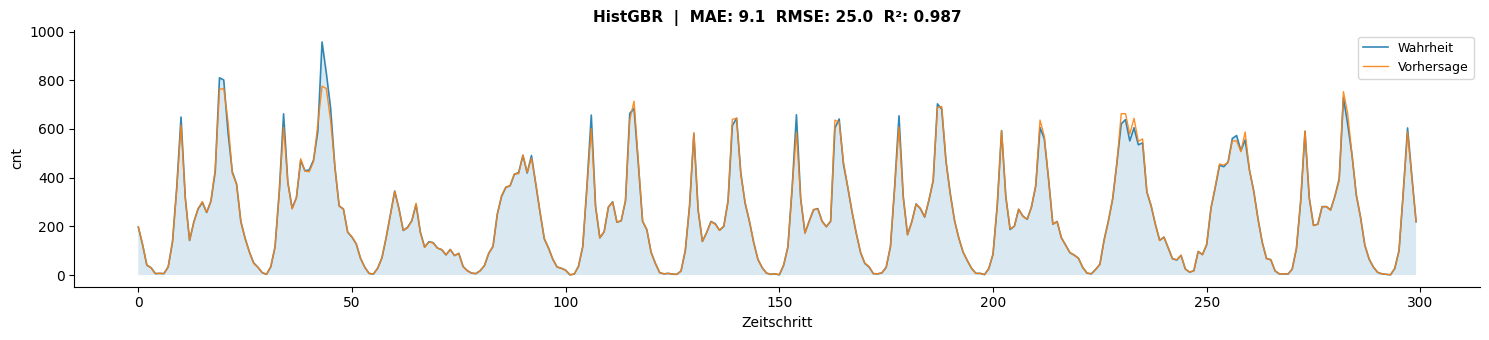

In [8]:
hgb = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=63,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(hgb, X_train, y_train, ts_cv)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
metrics_hgb = compute_metrics(y_test, y_pred_hgb)

result_hgb = {'name': 'HistGBR', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_hgb, **metrics_hgb}
all_results.append(result_hgb)
plot_predictions(result_hgb, y_test)

### Modellierung am Beispiel eines RandomForestRegressors

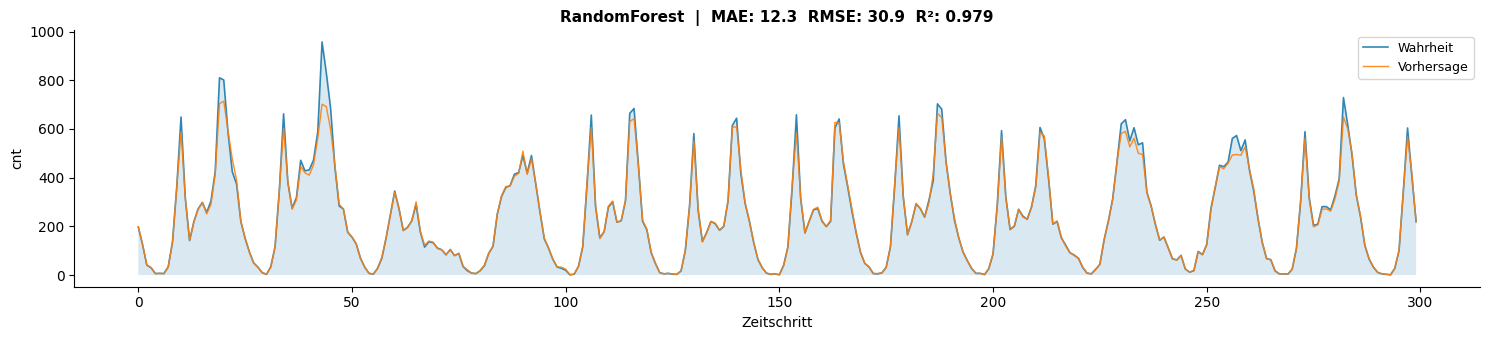

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(rf, X_train, y_train, ts_cv)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_rf = compute_metrics(y_test, y_pred_rf)

result_rf = {'name': 'RandomForest', 'cv_mae': cv_mae, 'cv_std': cv_std,
             'y_pred': y_pred_rf, **metrics_rf}
all_results.append(result_rf)
plot_predictions(result_rf, y_test)

### Modellierung am Beispiel von CatBoost
#### Warum wird CatBoost verwendet? 

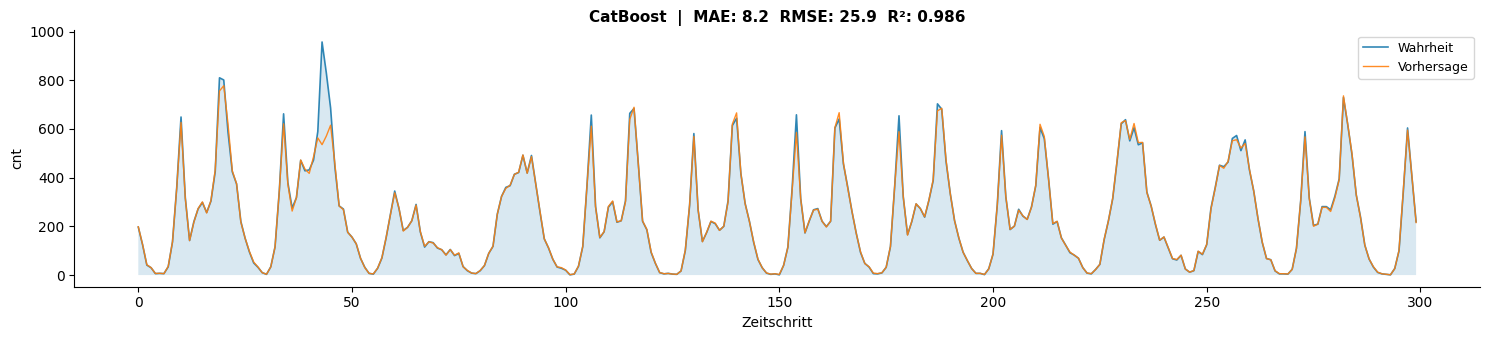

In [10]:
cat_model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.04,
    depth=7,
    min_data_in_leaf=10,
    subsample=0.8,
    random_seed=RANDOM_STATE,
    verbose=0
)

cv_mae, cv_std = cross_validate_ts(cat_model, X_train, y_train, ts_cv)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
metrics_cat = compute_metrics(y_test, y_pred_cat)

result_cat = {'name': 'CatBoost', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_cat, **metrics_cat}
all_results.append(result_cat)
plot_predictions(result_cat, y_test)

In [17]:
X_train

,instant,yr,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,...,hr_21,hr_22,hr_23,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,1,0,0,0,0.24,0.2879,0.81,0.0000,3,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0,0,0,0.22,0.2727,0.80,0.0000,8,32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,0,0,0,0.22,0.2727,0.80,0.0000,5,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,0,0,0,0.24,0.2879,0.75,0.0000,3,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,0,0,0,0.24,0.2879,0.75,0.0000,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10574,10575,1,0,1,0.60,0.5909,0.69,0.0896,113,616,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10575,10576,1,0,1,0.60,0.5909,0.69,0.0000,152,627,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10576,10577,1,0,1,0.60,0.6061,0.64,0.0000,86,496,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10577,10578,1,0,1,0.56,0.5303,0.78,0.0896,76,298,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Modellierung am Beispiel von TabPFN
#### Was ist TabPFN?
[ToDo]


In [11]:
load_dotenv()

os.environ["TABPFN_TOKEN"] = os.getenv("TABPFN_TOKEN")


TABPFN_MAX_TRAIN = 10_000

if len(X_train) > TABPFN_MAX_TRAIN:
    X_train_tab = X_train.iloc[-TABPFN_MAX_TRAIN:]
    y_train_tab = y_train.iloc[-TABPFN_MAX_TRAIN:]
else:
    X_train_tab = X_train
    y_train_tab = y_train

print(f'TabPFN Trainingssubset: {len(X_train_tab)} Samples, {X_train_tab.shape[1]} Features')

tabpfn = TabPFNRegressor(
    n_estimators=8,
    device='cpu',
    ignore_pretraining_limits=True,
)

# Cross-Validation auf dem Subset
ts_cv_tab = TimeSeriesSplit(n_splits=3, test_size=500)
cv_mae_tab, cv_std_tab = cross_validate_ts(tabpfn, X_train_tab, y_train_tab, ts_cv_tab)

tabpfn.fit(X_train_tab, y_train_tab)
y_pred_tabpfn = tabpfn.predict(X_test)
metrics_tabpfn = compute_metrics(y_test, y_pred_tabpfn)

result_tabpfn = {
    'name':    'TabPFN',
    'cv_mae':  cv_mae_tab,
    'cv_std':  cv_std_tab,
    'y_pred':  y_pred_tabpfn,
    'note':    f'Subset (letzte {len(X_train_tab)} Trainings-Samples)',
    **metrics_tabpfn,
}
all_results.append(result_tabpfn)
plot_predictions(result_tabpfn, y_test)

TabPFN Trainingssubset: 10000 Samples, 61 Features


KeyboardInterrupt: 

## Vergleich 

In [12]:
rows = []
for r in all_results:
    if r['cv_mae'] is not None:
        cv_str = f"{r['cv_mae']:.1f} ± {r['cv_std']:.1f}"
    else:
        cv_str = f"n/a ({r.get('note', 'Subset')})"
    rows.append({
        'Methode':   r['name'],
        'CV-MAE':    cv_str,
        'Test MAE':  round(r['MAE'], 2),
        'Test RMSE': round(r['RMSE'], 2),
        'Test R²':   round(r['R2'], 4),
        'Hinweis':   r.get('note', '–'),
    })

results_df = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
results_df

,Methode,CV-MAE,Test MAE,Test RMSE,Test R²,Hinweis
0,CatBoost,4.0 ± 2.1,8.16,25.93,0.9856,–
1,HistGBR,2.6 ± 1.4,9.13,24.97,0.9866,–
2,RandomForest,5.4 ± 2.1,12.34,30.92,0.9795,–


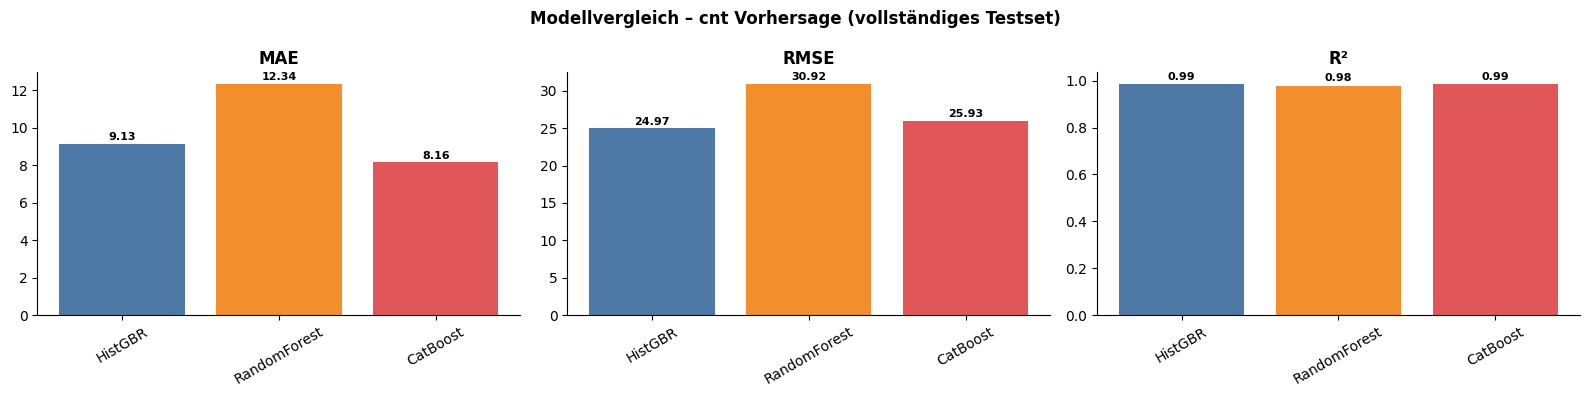

In [13]:
COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1','#ff9da7']

full_results = [r for r in all_results if len(r['y_pred']) >= 300]
names_full   = [r['name'] for r in full_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, label in zip(axes, ['MAE', 'RMSE', 'R2'], ['MAE', 'RMSE', 'R²']):
    vals = [r[metric] for r in full_results]
    bars = ax.bar(names_full, vals, color=COLORS[:len(names_full)], linewidth=0.5)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Modellvergleich – cnt Vorhersage (vollständiges Testset)', fontweight='bold')
plt.tight_layout()
plt.show()


#### Ohne Datum
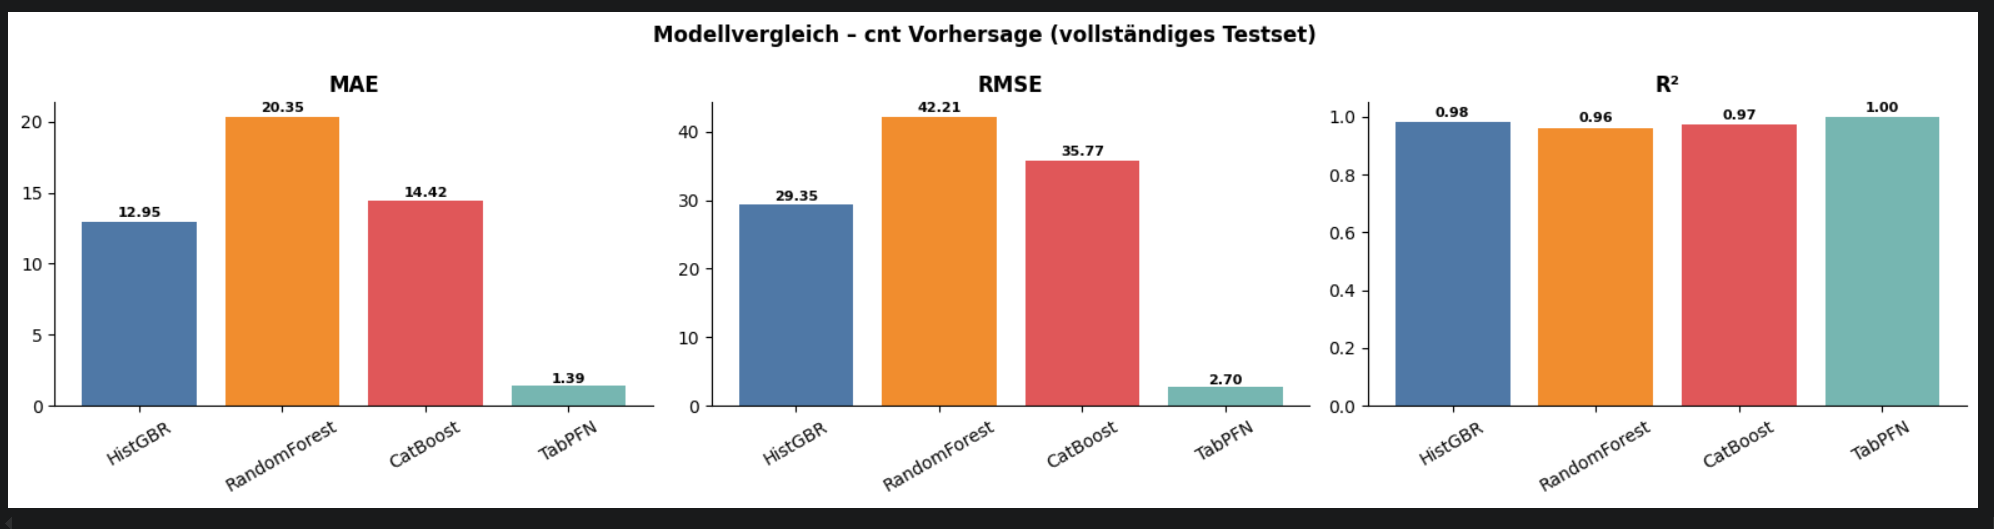
#### Mit Datum
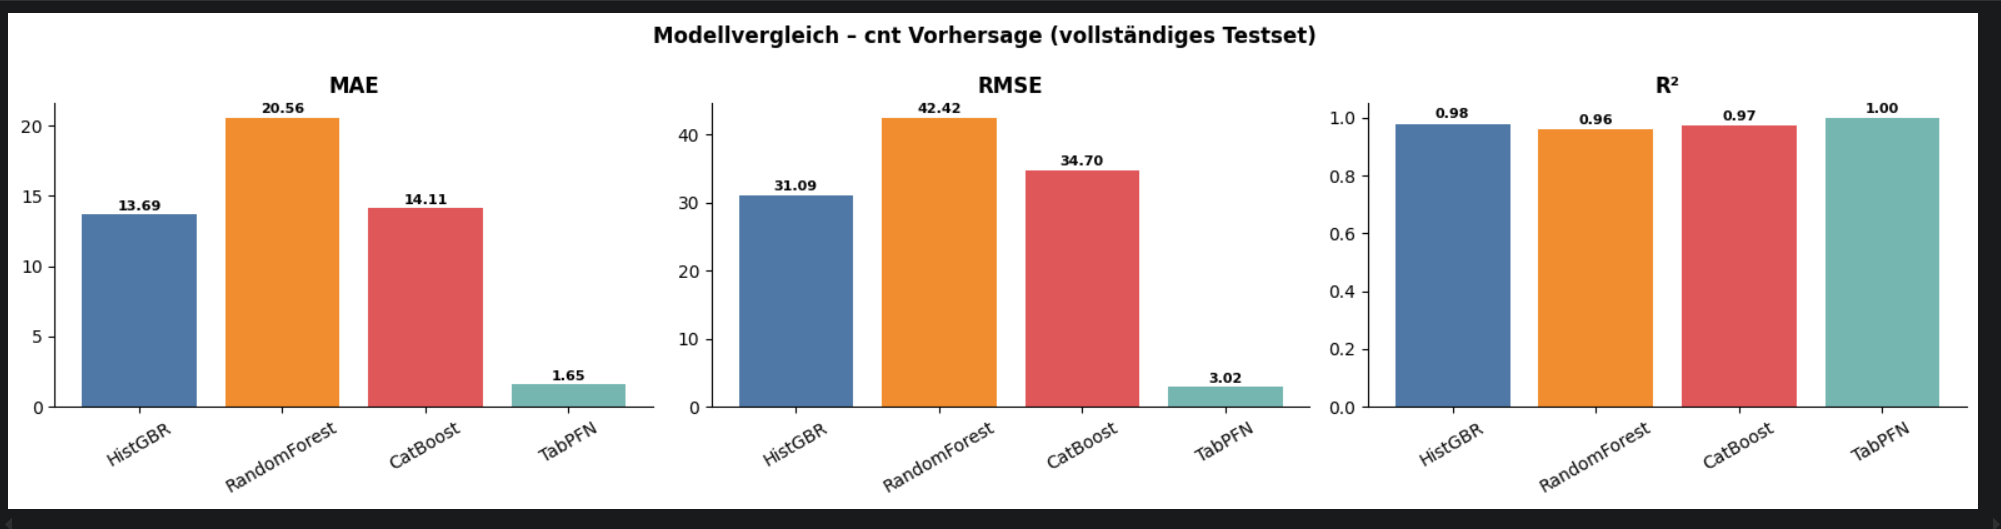

## Hauptkomponentenanalyse / Primärkomponentenanalyse

Komponenten für 90 % Varianz: 41
Komponenten für 95 % Varianz: 44
Komponenten für 99 % Varianz: 49
Gesamtzahl Features: 61


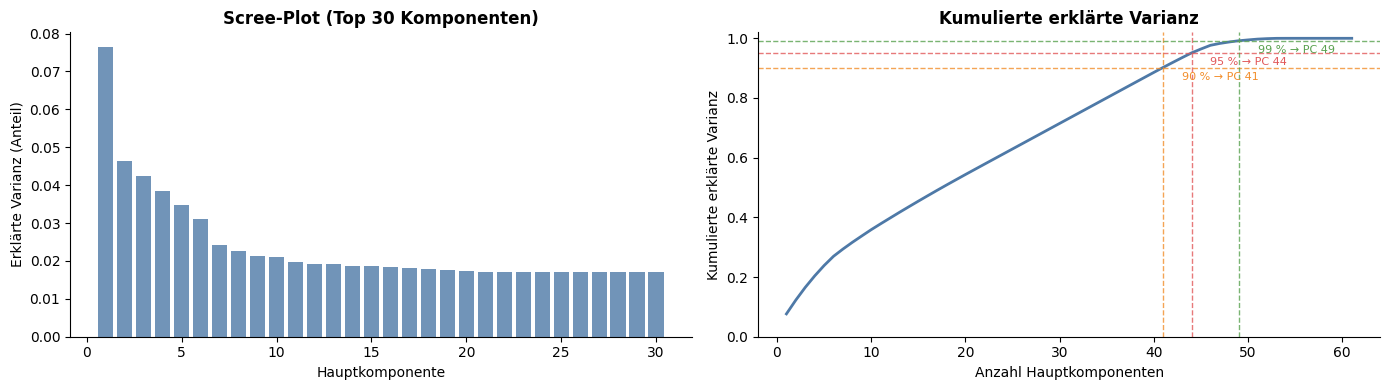

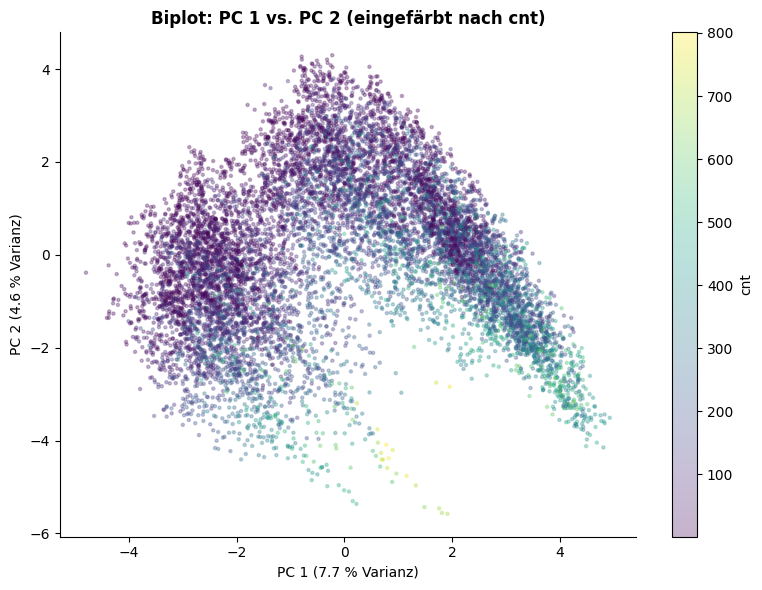

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n90 = np.searchsorted(cumulative, 0.90) + 1
n95 = np.searchsorted(cumulative, 0.95) + 1
n99 = np.searchsorted(cumulative, 0.99) + 1
print(f"Komponenten für 90 % Varianz: {n90}")
print(f"Komponenten für 95 % Varianz: {n95}")
print(f"Komponenten für 99 % Varianz: {n99}")
print(f"Gesamtzahl Features: {X_train.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scree-Plot
axes[0].bar(range(1, 31), explained[:30], color='#4e79a7', alpha=0.8)
axes[0].set_xlabel('Hauptkomponente')
axes[0].set_ylabel('Erklärte Varianz (Anteil)')
axes[0].set_title('Scree-Plot (Top 30 Komponenten)', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Kumulative erklärte Varianz
axes[1].plot(range(1, len(cumulative) + 1), cumulative, lw=2, color='#4e79a7')
for threshold, color, label in [(0.90, '#f28e2b', '90 %'), (0.95, '#e15759', '95 %'), (0.99, '#59a14f', '99 %')]:
    n = np.searchsorted(cumulative, threshold) + 1
    axes[1].axhline(threshold, color=color, ls='--', lw=1, alpha=0.8)
    axes[1].axvline(n, color=color, ls='--', lw=1, alpha=0.8)
    axes[1].annotate(f'{label} → PC {n}', xy=(n, threshold),
                     xytext=(n + 2, threshold - 0.04), fontsize=8, color=color)
axes[1].set_xlabel('Anzahl Hauptkomponenten')
axes[1].set_ylabel('Kumulierte erklärte Varianz')
axes[1].set_title('Kumulierte erklärte Varianz', fontweight='bold')
axes[1].set_ylim(0, 1.02)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Biplot der ersten zwei Hauptkomponenten
X_pca2 = pca.transform(X_train_scaled)[:, :2]
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
                c=y_train.values, cmap='viridis', alpha=0.3, s=5, rasterized=True)
plt.colorbar(sc, ax=ax, label='cnt')
ax.set_xlabel(f'PC 1 ({explained[0]*100:.1f} % Varianz)')
ax.set_ylabel(f'PC 2 ({explained[1]*100:.1f} % Varianz)')
ax.set_title('Biplot: PC 1 vs. PC 2 (eingefärbt nach cnt)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Feature Importance

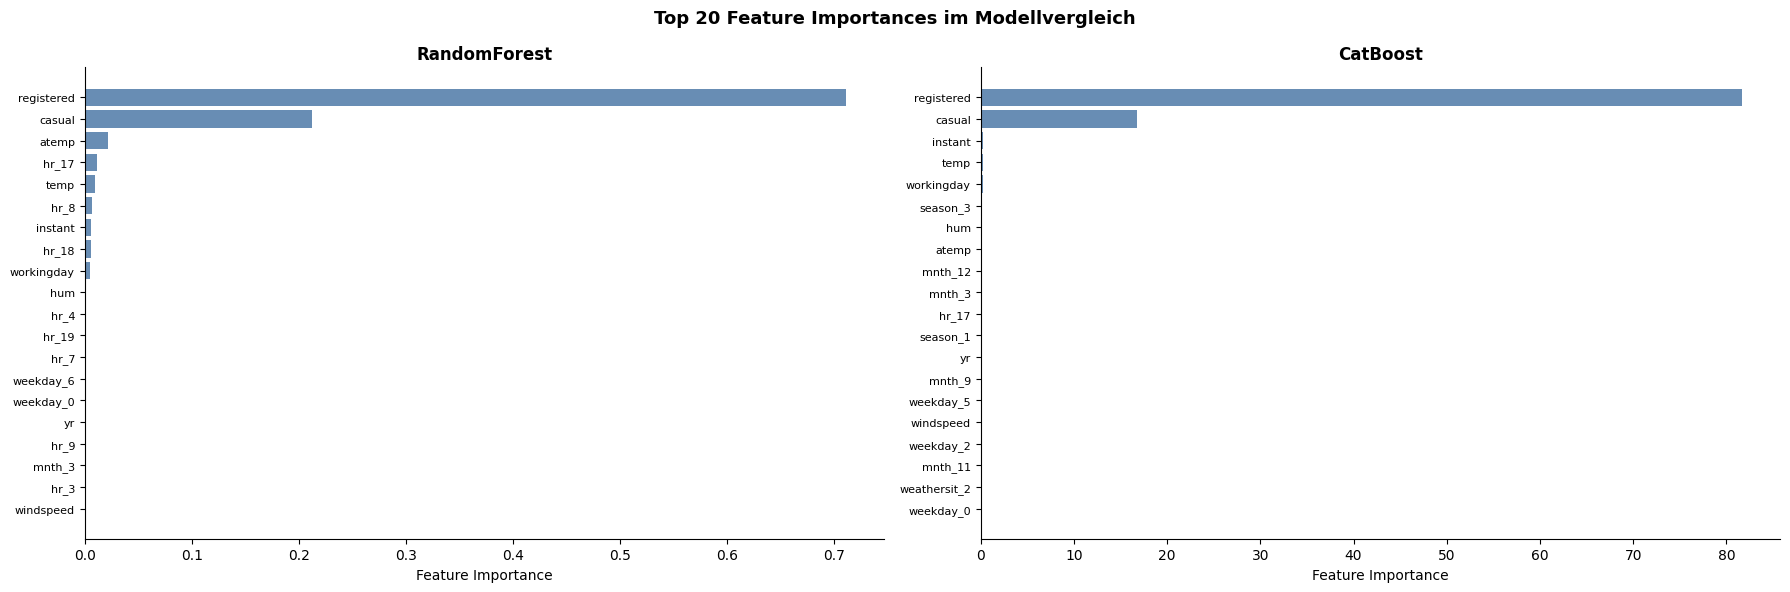

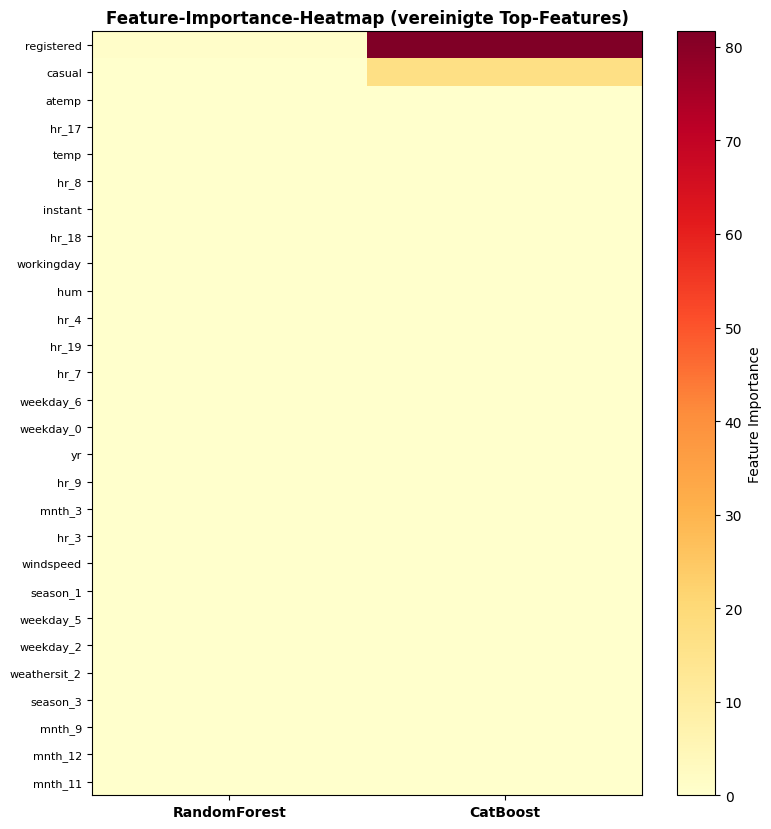

In [16]:
TOP_N = 20
feature_names = X_train.columns.tolist()

models_fi = {
    'RandomForest':  rf.feature_importances_,
    #'HistGBR':       hgb.feature_importances_,
    'CatBoost':      cat_model.feature_importances_,
}

fig, axes = plt.subplots(1, len(models_fi), figsize=(18, 6))

for ax, (model_name, importances) in zip(axes, models_fi.items()):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top = fi.head(TOP_N)
    ax.barh(top.index[::-1], top.values[::-1], color='#4e79a7', alpha=0.85)
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Top {TOP_N} Feature Importances im Modellvergleich', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Übereinstimmungs-Heatmap: Top-Features aller Modelle kombiniert
all_top = set()
for imp in models_fi.values():
    fi = pd.Series(imp, index=feature_names).sort_values(ascending=False)
    all_top.update(fi.head(TOP_N).index.tolist())

fi_matrix = pd.DataFrame(
    {name: pd.Series(imp, index=feature_names) for name, imp in models_fi.items()},
    index=list(all_top)
).sort_values('RandomForest', ascending=False)

fig, ax = plt.subplots(figsize=(8, max(6, len(fi_matrix) * 0.3)))
im = ax.imshow(fi_matrix.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(fi_matrix.columns)))
ax.set_xticklabels(fi_matrix.columns, fontweight='bold')
ax.set_yticks(range(len(fi_matrix.index)))
ax.set_yticklabels(fi_matrix.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Feature Importance')
ax.set_title('Feature-Importance-Heatmap (vereinigte Top-Features)', fontweight='bold')
plt.tight_layout()
plt.show()